<a href="https://colab.research.google.com/github/hre1oo/ARTI308_Machine-learning/blob/LAB_4/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB4_Data Quality Assessment & Preprocessing

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('Titanic-Dataset.csv')
print("Missing values before imputation:\n", df.isna().sum())

df_imputed = df.copy()
df_imputed['Age'].fillna(df_imputed['Age'].median(), inplace=True)

df_imputed['Embarked'].fillna(df_imputed['Embarked'].mode()[0], inplace=True)

print("\nMissing values after imputation:\n", df_imputed[['Age', 'Embarked']].isna().sum())

Missing values before imputation:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after imputation:
 Age         0
Embarked    0
dtype: int64


/tmp/ipython-input-283/1642619544.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed['Age'].fillna(df_imputed['Age'].median(), inplace=True)
/tmp/ipython-input-283/1642619544.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [10]:
Q1 = df_imputed['Fare'].quantile(0.25)
Q3 = df_imputed['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_imputed[(df_imputed['Fare'] < lower_bound) | (df_imputed['Fare'] > upper_bound)]
print(f"Number of outlier fares detected: {len(outliers)}")

df_cleaned = df_imputed.copy()
df_cleaned['Fare'] = df_cleaned['Fare'].clip(lower=df_cleaned['Fare'].min(), upper=upper_bound)

Number of outlier fares detected: 116


In [11]:
numeric_cols = ['Age', 'Fare']

minmax_scaler = MinMaxScaler()
df_minmax = df_cleaned.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax[numeric_cols])
print("\nMin-Max Normalized Data (first 5 rows):\n", df_minmax[numeric_cols].head())

standard_scaler = StandardScaler()
df_standardized = df_cleaned.copy()
df_standardized[numeric_cols] = standard_scaler.fit_transform(df_standardized[numeric_cols])
print("\nZ-Score Standardized Data (first 5 rows):\n", df_standardized[numeric_cols].head())


Min-Max Normalized Data (first 5 rows):
         Age      Fare
0  0.271174  0.110460
1  0.472229  1.000000
2  0.321438  0.120745
3  0.434531  0.809027
4  0.434531  0.122649

Z-Score Standardized Data (first 5 rows):
         Age      Fare
0 -0.565736 -0.820552
1  0.663861  2.031623
2 -0.258337 -0.787578
3  0.433312  1.419297
4  0.433312 -0.781471



Explained Variance Ratio: [0.43423382 0.28378057]
Total Variance Captured by 2 components: 71.80%


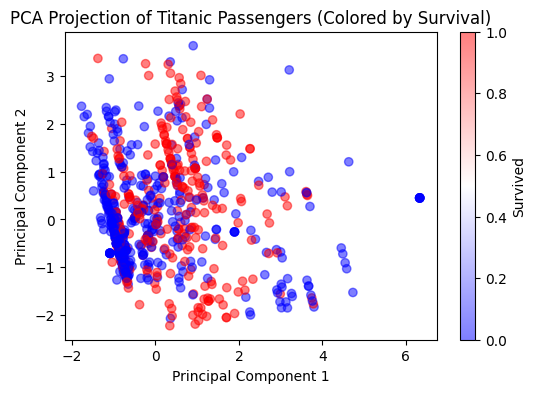

In [12]:
features_for_pca = ['Age', 'Fare', 'SibSp', 'Parch']

df_standardized[features_for_pca] = standard_scaler.fit_transform(df_cleaned[features_for_pca])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_standardized[features_for_pca])

explained_variance = pca.explained_variance_ratio_
print(f"\nExplained Variance Ratio: {explained_variance}")
print(f"Total Variance Captured by 2 components: {sum(explained_variance) * 100:.2f}%")

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.5, c=df_cleaned['Survived'], cmap='bwr')
plt.title("PCA Projection of Titanic Passengers (Colored by Survival)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Survived')
plt.show()